In [5]:
from pathlib import Path

import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

BASE_DIR = Path.cwd()
PROJECT_DIR = BASE_DIR if (BASE_DIR / 'sleeve_model.py').exists() else BASE_DIR.parent
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from sleeve_model import SleeveCNNAttentionImproved

In [3]:
OUTPUT_DIR = PROJECT_DIR / 'outputs_v16_best'
CONFIG_PATH = OUTPUT_DIR / 'config.json'
MODEL_PATH = OUTPUT_DIR / 'best_model.pt'

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f'Missing config: {CONFIG_PATH}')
if not MODEL_PATH.exists():
    raise FileNotFoundError(f'Missing checkpoint: {MODEL_PATH}')

with open(CONFIG_PATH, 'r') as f:
    config = json.load(f)

print(f'Project dir: {PROJECT_DIR}')
print(f'Output dir : {OUTPUT_DIR}')
config

Project dir: c:\Users\NML\Documents\Github\sEMG-model\sEMG_sleeve
Output dir : c:\Users\NML\Documents\Github\sEMG-model\sEMG_sleeve\outputs_v16_best


{'model': {'model_key': 'baseline',
  'architecture': 'SleeveCNNAttentionImproved',
  'n_ch': 128,
  'window_size': 200,
  'n_joints': 14,
  'hidden': 256,
  'n_attn': 4,
  'n_heads': 2,
  'kernel_size': -1,
  'dilations': [],
  'geom_ch': -1,
  'cnn_activation': 'elu',
  'attn_ff_activation': 'gelu',
  'mlp_activation': 'relu',
  'parameters': 4408930},
 'training': {'batch_size': 64,
  'epochs': 150,
  'lr': 5e-05,
  'eta_min': 3e-05,
  'warmup_epochs': 5,
  'weight_decay': 0.0003,
  'dropout': 0.2,
  'optimizer': 'AdamW',
  'scheduler': 'CosineAnnealingLR',
  'loss': 'SmoothL1Loss(beta=0.5)',
  'grad_clip': 1.0,
  'seed': 42},
 'data': {'data_source': 'processed',
  'data_dir': 'C:\\Users\\NML\\Documents\\Github\\sEMG-model\\sEMG_sleeve\\processed data',
  'train_samples': 95709,
  'val_samples': 23910,
  'emg_shape': [95709, 128, 200],
  'paper_replication': False,
  'emg_transform': 'none',
  'input_mode': 'raw',
  'rms_subframes': 100,
  'input_scaler': 'standard',
  'target_scal

In [6]:
model_cfg = config['model']
model = SleeveCNNAttentionImproved(
    n_ch=int(model_cfg['n_ch']),
    window_size=int(model_cfg['window_size']),
    n_joints=int(model_cfg['n_joints']),
    hidden=int(model_cfg['hidden']),
    n_attn=int(model_cfg['n_attn']),
    n_heads=int(model_cfg['n_heads']),
    dropout=float(config['training']['dropout']),
)

state_dict = torch.load(MODEL_PATH, map_location='cpu')
model.load_state_dict(state_dict)
model.eval()

print(f"Loaded model with {model.count_params():,} trainable params")
sorted(state_dict.keys())[:12]

Loaded model with 4,408,930 trainable params


['attn_layers.0.attn.in_proj_bias',
 'attn_layers.0.attn.in_proj_weight',
 'attn_layers.0.attn.out_proj.bias',
 'attn_layers.0.attn.out_proj.weight',
 'attn_layers.0.ff.0.bias',
 'attn_layers.0.ff.0.weight',
 'attn_layers.0.ff.3.bias',
 'attn_layers.0.ff.3.weight',
 'attn_layers.0.norm1.bias',
 'attn_layers.0.norm1.weight',
 'attn_layers.0.norm2.bias',
 'attn_layers.0.norm2.weight']

In [8]:
pre_weight = model.pre[0].weight.detach().cpu().numpy()
hidden = model.hidden
n_ch = model.n_ch
circ_out = model.circ.bn.num_features

print('pre weight shape:', pre_weight.shape)
print('hidden:', hidden, 'channels:', n_ch, 'circ_out:', circ_out)

pre_weight = pre_weight[:, :, 0]  # (hidden, 16*n_ch)
channel_tensor = pre_weight.reshape(hidden, circ_out, n_ch)
channel_embeddings = channel_tensor.transpose(2, 0, 1).reshape(n_ch, hidden * circ_out)

channel_df = pd.DataFrame({
    'channel': np.arange(n_ch),
    'l2_norm': np.linalg.norm(channel_embeddings, axis=1),
    'abs_mean': np.mean(np.abs(channel_embeddings), axis=1),
})

channel_df.describe()

pre weight shape: (256, 2048, 1)
hidden: 256 channels: 128 circ_out: 16


,channel,l2_norm,abs_mean
count,128.000000,128.000000,128.000000
mean,63.500000,1.416715,0.017640
std,37.094474,0.095628,0.001112
min,0.000000,1.120530,0.014208
25%,31.750000,1.350097,0.016839
50%,63.500000,1.420093,0.017699
75%,95.250000,1.484528,0.018457
max,127.000000,1.779752,0.021997


In [9]:
def pca_svd(X, n_components=3):
    X = np.asarray(X, dtype=np.float64)
    X_mean = X.mean(axis=0, keepdims=True)
    X_centered = X - X_mean
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    scores = X_centered @ Vt[:n_components].T
    explained = (S**2) / max(1, X.shape[0] - 1)
    explained_ratio = explained / explained.sum()
    return {
        'scores': scores,
        'components': Vt[:n_components],
        'mean': X_mean,
        'explained_ratio': explained_ratio[:n_components],
    }

pca = pca_svd(channel_embeddings, n_components=3)
scores = pca['scores']
explained_ratio = pca['explained_ratio']

channel_pca_df = channel_df.copy()
channel_pca_df['pc1'] = scores[:, 0]
channel_pca_df['pc2'] = scores[:, 1]
channel_pca_df['pc3'] = scores[:, 2]

print('Explained variance ratio:', explained_ratio)
channel_pca_df.head()

Explained variance ratio: [0.01669124 0.01568209 0.01534095]


,channel,l2_norm,abs_mean,pc1,pc2,pc3
0,0,1.299266,0.016196,-0.070970,0.016174,-0.017157
1,1,1.379044,0.017250,-0.025891,0.088188,0.067503
2,2,1.500050,0.018537,-0.133382,0.049528,0.066220
3,3,1.456464,0.018072,-0.032445,0.050690,0.055954
4,4,1.351593,0.016910,-0.084106,0.044975,-0.043933


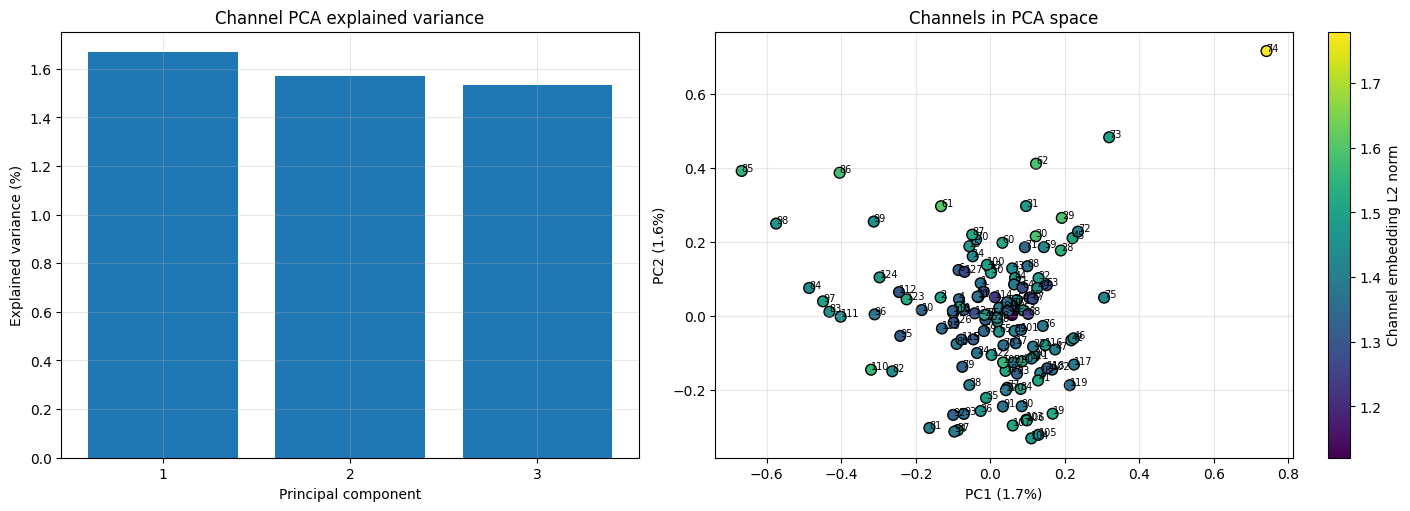

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].bar([1, 2, 3], explained_ratio * 100.0)
axes[0].set_xticks([1, 2, 3])
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance (%)')
axes[0].set_title('Channel PCA explained variance')
axes[0].grid(True, alpha=0.3)

sc = axes[1].scatter(
    channel_pca_df['pc1'],
    channel_pca_df['pc2'],
    c=channel_pca_df['l2_norm'],
    cmap='viridis',
    s=60,
    edgecolor='k',
)
for _, row in channel_pca_df.iterrows():
    axes[1].text(row['pc1'], row['pc2'], str(int(row['channel'])), fontsize=7)
axes[1].set_xlabel(f"PC1 ({explained_ratio[0] * 100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({explained_ratio[1] * 100:.1f}%)")
axes[1].set_title('Channels in PCA space')
axes[1].grid(True, alpha=0.3)
plt.colorbar(sc, ax=axes[1], label='Channel embedding L2 norm')

plt.show()

In [11]:
top_pc1_pos = channel_pca_df.sort_values('pc1', ascending=False).head(10)
top_pc1_neg = channel_pca_df.sort_values('pc1', ascending=True).head(10)
top_pc2_pos = channel_pca_df.sort_values('pc2', ascending=False).head(10)
top_pc2_neg = channel_pca_df.sort_values('pc2', ascending=True).head(10)

print('Top +PC1 channels:')
display(top_pc1_pos[['channel', 'pc1', 'pc2', 'l2_norm']])
print('Top -PC1 channels:')
display(top_pc1_neg[['channel', 'pc1', 'pc2', 'l2_norm']])
print('Top +PC2 channels:')
display(top_pc2_pos[['channel', 'pc1', 'pc2', 'l2_norm']])
print('Top -PC2 channels:')
display(top_pc2_neg[['channel', 'pc1', 'pc2', 'l2_norm']])

Top +PC1 channels:


,channel,pc1,pc2,l2_norm
74,74,0.741154,0.715196,1.779752
73,73,0.318919,0.482266,1.494503
75,75,0.305374,0.049194,1.425897
72,72,0.235183,0.227520,1.412987
117,117,0.224501,-0.131428,1.387130
46,46,0.223575,-0.060611,1.430287
45,45,0.220760,0.210194,1.509817
42,42,0.216980,-0.065907,1.502676
119,119,0.213283,-0.187325,1.358626
29,29,0.191839,0.264647,1.590315


Top -PC1 channels:


,channel,pc1,pc2,l2_norm
85,85,-0.667084,0.391404,1.549986
98,98,-0.574715,0.249327,1.454966
84,84,-0.486071,0.075364,1.434962
97,97,-0.448884,0.039260,1.500112
83,83,-0.431747,0.011157,1.466980
86,86,-0.404262,0.386423,1.581367
111,111,-0.401429,-0.002341,1.441178
110,110,-0.319927,-0.145403,1.567406
99,99,-0.312773,0.254711,1.448585
96,96,-0.310395,0.004057,1.369522


Top +PC2 channels:


,channel,pc1,pc2,l2_norm
74,74,0.741154,0.715196,1.779752
73,73,0.318919,0.482266,1.494503
62,62,0.122599,0.410861,1.589262
85,85,-0.667084,0.391404,1.549986
86,86,-0.404262,0.386423,1.581367
31,31,0.095924,0.296622,1.482293
61,61,-0.132223,0.296227,1.606437
29,29,0.191839,0.264647,1.590315
99,99,-0.312773,0.254711,1.448585
98,98,-0.574715,0.249327,1.454966


Top -PC2 channels:


,channel,pc1,pc2,l2_norm
104,104,0.109976,-0.330723,1.469632
105,105,0.129176,-0.321218,1.434553
94,94,-0.096469,-0.312466,1.388824
37,37,-0.087224,-0.308425,1.507590
81,81,-0.163523,-0.302748,1.412951
107,107,0.060181,-0.296002,1.507800
106,106,0.098185,-0.282114,1.500602
103,103,0.096522,-0.280226,1.420737
92,92,-0.099615,-0.267376,1.332119
93,93,-0.070929,-0.264741,1.360292


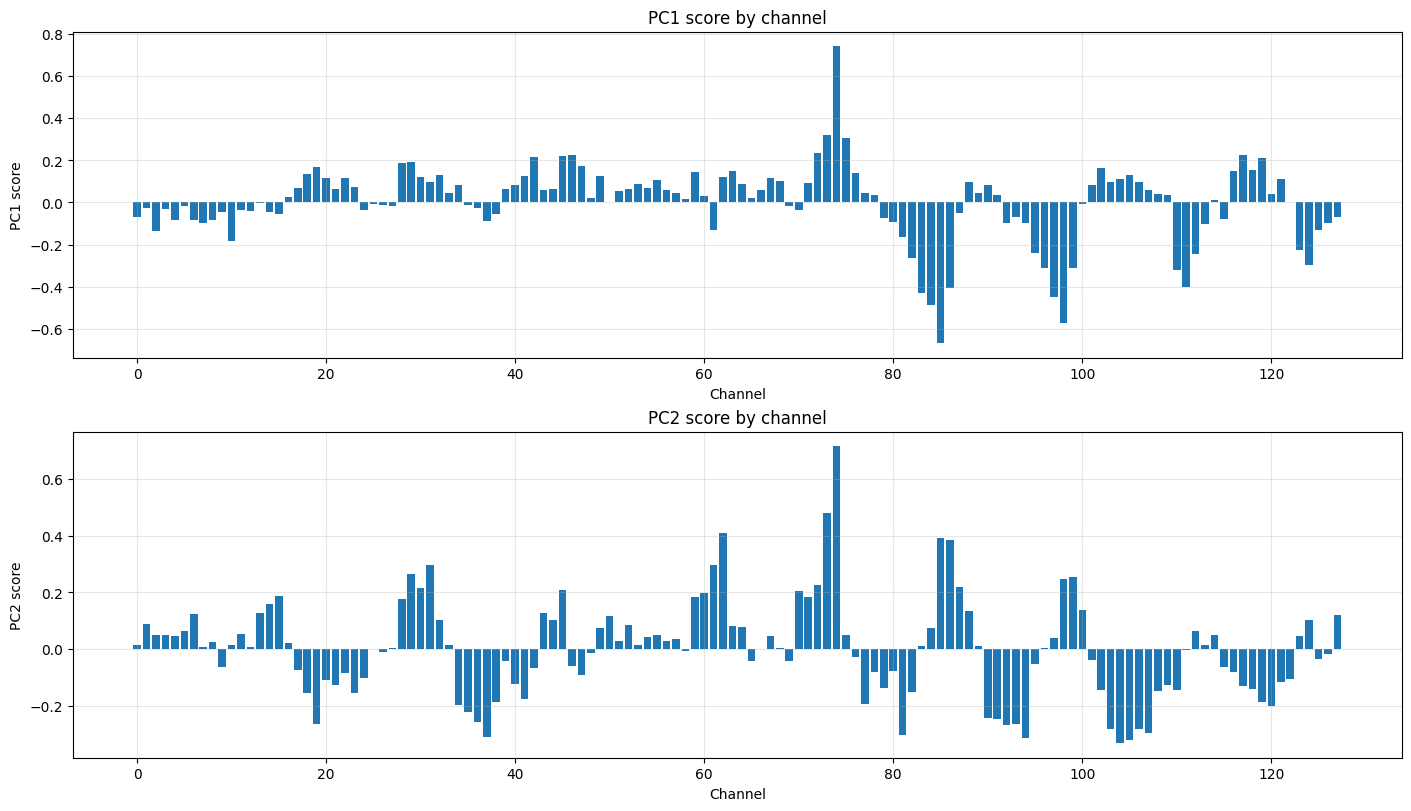

PC1 channel ordering (low → high):
[85, 98, 84, 97, 83, 86, 111, 110, 99, 96, 124, 82, 112, 95, 123, 10, 81, 2, 61, 125, 113, 92, 7, 126, 94, 80, 37, 6, 4, 8, 115, 79, 0, 93, 127, 38, 15, 87, 14, 9, 12, 70, 24, 11, 3, 1, 36, 5, 69, 27, 26, 35, 100, 25, 13, 50, 122, 114, 58, 48, 65, 16, 60, 91, 109, 78, 108, 120, 33, 57, 77, 89, 51, 56, 66, 43, 107, 21, 52, 39, 44, 17, 54, 23, 34, 101, 90, 40, 64, 53, 71, 31, 103, 106, 88, 68, 55, 104, 121, 67, 22, 20, 30, 62, 49, 41, 105, 32, 18, 76, 59, 116, 63, 118, 102, 19, 47, 28, 29, 119, 42, 45, 46, 117, 72, 75, 73, 74]
PC2 channel ordering (low → high):
[104, 105, 94, 37, 81, 107, 106, 103, 92, 93, 19, 36, 91, 90, 35, 120, 34, 77, 119, 38, 41, 23, 18, 82, 108, 110, 102, 118, 79, 117, 109, 21, 40, 121, 20, 122, 24, 47, 22, 78, 116, 80, 17, 42, 115, 9, 46, 95, 65, 69, 39, 101, 125, 76, 126, 48, 26, 58, 111, 25, 66, 27, 96, 68, 12, 7, 83, 89, 113, 53, 33, 10, 0, 16, 8, 56, 51, 57, 97, 54, 123, 4, 67, 75, 2, 55, 114, 3, 11, 112, 5, 49, 84, 64, 63, 5

In [12]:
pc1_order = channel_pca_df.sort_values('pc1')['channel'].to_numpy()
pc2_order = channel_pca_df.sort_values('pc2')['channel'].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)
axes[0].bar(channel_pca_df['channel'], channel_pca_df['pc1'])
axes[0].set_title('PC1 score by channel')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('PC1 score')
axes[0].grid(True, alpha=0.3)

axes[1].bar(channel_pca_df['channel'], channel_pca_df['pc2'])
axes[1].set_title('PC2 score by channel')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('PC2 score')
axes[1].grid(True, alpha=0.3)

plt.show()

print('PC1 channel ordering (low → high):')
print(pc1_order.tolist())
print('PC2 channel ordering (low → high):')
print(pc2_order.tolist())